# Regime Detection using k-means and jump models

## 1. Loading data and constructing features

In [1]:
import pandas as pd 
import logging
from datetime import datetime
import requests # new import 
from io import StringIO # new import
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
import cvxportfolio as cp
import yfinance as yf

/home/ndntam/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [99]:
START_DATE = (pd.Timestamp('1999-01-01').normalize() + pd.Timedelta(hours=16)).tz_localize('US/Eastern')
END_DATE = (pd.Timestamp('2025-12-31').normalize() + pd.Timedelta(hours=16)).tz_localize('US/Eastern')

spy_df = yf.download('SPY', start=START_DATE, end=END_DATE).xs('SPY', axis = 1, level = 1)
spy_df.to_csv("SPY.csv")
spy_df['logprice'] = spy_df['Close'].apply(np.log).shift(1)
spy_df['logvol'] = spy_df['Volume'].apply(np.log).shift(1)

[*********************100%***********************]  1 of 1 completed


In [113]:
spy_df.index = spy_df.index.normalize() + pd.Timedelta(hours=16)
spy_df.index = spy_df.index.tz_localize('US/Eastern')

for WINDOW in [3, 20, 50, 200]:
    spy_df[f'ma{WINDOW}'] = spy_df['logprice'].rolling(window = WINDOW, min_periods = 1).mean() 

In [5]:
spy_df

Price,Close,High,Low,Open,Volume,logprice,logvol,ma3,ma20,ma50,ma200
Date,,,,,,,,,,,
1999-01-04 16:00:00-05:00,76.677498,78.040827,75.859501,76.891735,9450400,NaN,NaN,NaN,NaN,NaN,NaN
1999-01-05 16:00:00-05:00,77.553978,77.826644,76.619123,76.619123,8031000,4.339608,16.061568,4.339608,4.339608,4.339608,4.339608
1999-01-06 16:00:00-05:00,79.423630,79.618391,78.371919,78.410871,7737700,4.350974,15.898820,4.345291,4.345291,4.345291,4.345291
1999-01-07 16:00:00-05:00,79.034111,79.287301,78.391399,78.761445,5504900,4.374796,15.861615,4.355126,4.355126,4.355126,4.355126
1999-01-08 16:00:00-05:00,79.618401,80.085828,78.508261,79.891066,6224400,4.369880,15.521149,4.365217,4.358814,4.358814,4.358814
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24 16:00:00-05:00,690.380005,690.830017,687.799988,687.950012,39445600,6.533731,17.987433,6.528620,6.522493,6.513663,6.426625
2025-12-26 16:00:00-05:00,690.309998,691.659973,689.270020,690.640015,41613300,6.537242,17.490433,6.533381,6.523766,6.514554,6.427766
2025-12-29 16:00:00-05:00,687.849976,689.200012,686.070007,687.539978,62559500,6.537141,17.543930,6.536038,6.524689,6.515355,6.428880


In [6]:
def construct_features(df):
    
    feature_df = pd.DataFrame(index = df.index)
    #df['logprice'] = df[['PriceUSD_coinmetrics']].loc[START_DATE:END_DATE].apply(np.log)
    #logprice_df.columns = ['logprice']

    #df['logvol'] = df[['volume_reported_spot_usd_1d_coinmetrics']].loc[START_DATE:END_DATE].apply(np.log)
    #logvol_df.columns = ['logvol']

    #df['ret'] = df['logprice'].shift(1) - df['logprice'].shift(2)
    #df['vol'] = df['logvol'].shift(1) - df['logvol'].shift(2)
    
    to_concat = dict()
    
    # for WINDOW in [5, 15, 45]:
    #     to_concat[f'ema_{WINDOW}'] = df['ret'].ewm(halflife = WINDOW).mean()
    #     to_concat[f'vol_{WINDOW}'] = df['vol'].ewm(halflife = WINDOW).mean() 
    #     to_concat[f'rho_{WINDOW}'] = df['ret'].ewm(halflife = WINDOW).corr(df['vol'])
       
    for WINDOW in [30, 90, 180, 365, 1461]:
        past = df['logprice'].loc[START_DATE:END_DATE]
        mean = past.rolling(window = WINDOW, min_periods =1).mean()
        std = past.rolling(window = WINDOW, min_periods = 1).std()
        to_concat[f'logprice_z{WINDOW}'] = (past - mean)/std
        #print(df[f'price_z{WINDOW}'])

    # for WINDOW in [3, 20, 50, 200]:
    #     past = df['logprice'].shift(1)
    #     to_concat[f'ma{WINDOW}'] = past.rolling(window = WINDOW, min_periods = 1).mean() 
        #to_concat[f'std{WINDOW}'] = past.rolling(window = WINDOW, min_periods = 1).std() 

    # print(to_concat)
    return pd.concat(to_concat, axis = 1)

In [7]:
features = construct_features(spy_df)

In [8]:
features

,logprice_z30,logprice_z90,logprice_z180,logprice_z365,logprice_z1461
Date,,,,,
1999-01-04 16:00:00-05:00,NaN,NaN,NaN,NaN,NaN
1999-01-05 16:00:00-05:00,NaN,NaN,NaN,NaN,NaN
1999-01-06 16:00:00-05:00,0.707107,0.707107,0.707107,0.707107,0.707107
1999-01-07 16:00:00-05:00,1.095353,1.095353,1.095353,1.095353,1.095353
1999-01-08 16:00:00-05:00,0.674151,0.674151,0.674151,0.674151,0.674151
...,...,...,...,...,...
2025-12-24 16:00:00-05:00,1.280584,1.543893,1.238129,1.834519,1.932375
2025-12-26 16:00:00-05:00,1.445214,1.664722,1.290408,1.864998,1.943817
2025-12-29 16:00:00-05:00,1.368801,1.632296,1.278672,1.849620,1.940545


## 2. Market regime classification - exploratory analysis

Improvements:
- [x] Penalty on number of transitions, in other words statistical jump models
- [ ] Try 3-state model
- [x] More data (volatility, fed rates, equity indices, sentiment, on-chain metrics, etc.). Combination of literature and self research shows current feature set gives highest Sharpe ratio
- [ ] Ignore points that are too close to decision boundaries
- [ ] Should try on-line learning (retrain with shifted window on a monthly/yearly basis?)

In [9]:
TOTAL_DAYS = END_DATE - START_DATE
TRAIN_START = START_DATE
TRAIN_END = pd.Timestamp("2020-01-06 16:00:00").tz_localize('US/Eastern')

TEST_START = pd.Timestamp("2020-01-07 16:00:00").tz_localize('US/Eastern')
TEST_END = END_DATE


# X = features[['CapMrktCurUSD_z90',\
#     'PriceUSD_z90',\
#     'CapMVRVCur_z180',\
#     'CapMrktCurUSD_z180',\
#     'PriceUSD_z180',\
#     'CapMVRVCur_z365']].bfill().dropna(axis=1, how='all')

X = features.dropna()

Xtrain = X[TRAIN_START:TRAIN_END]
Xtest = X[TEST_START:TEST_END]

In [10]:
Xtrain

,logprice_z30,logprice_z90,logprice_z180,logprice_z365,logprice_z1461
Date,,,,,
1999-01-06 16:00:00-05:00,0.707107,0.707107,0.707107,0.707107,0.707107
1999-01-07 16:00:00-05:00,1.095353,1.095353,1.095353,1.095353,1.095353
1999-01-08 16:00:00-05:00,0.674151,0.674151,0.674151,0.674151,0.674151
1999-01-11 16:00:00-05:00,0.897351,0.897351,0.897351,0.897351,0.897351
1999-01-12 16:00:00-05:00,0.289549,0.289549,0.289549,0.289549,0.289549
...,...,...,...,...,...
2019-12-30 16:00:00-05:00,1.883328,1.981670,2.410420,2.265999,2.013726
2019-12-31 16:00:00-05:00,1.408043,1.767510,2.220610,2.154043,1.980588
2020-01-02 16:00:00-05:00,1.452527,1.787296,2.238369,2.173089,1.990194


### Jump models

This is essentially $k$-means + penalizing the number of switches

In [11]:
from jumpmodels.jump import JumpModel
from jumpmodels.sparse_jump import SparseJumpModel
from jumpmodels.plot import plot_regimes_and_cumret, plot_regimes, savefig_plt

NO_STATES = 2
JUMP_PENALTY = 50
MAX_FEATS = 5
jump = JumpModel(n_components = NO_STATES, jump_penalty = JUMP_PENALTY, cont = False, ).fit(Xtrain)

In [12]:
plt.rcdefaults()
def plot(labels, start_date, end_date):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
    spy_df["Open"][start_date:end_date].apply(np.log).plot(ax = ax)
    ax.set(ylabel="LogPrice")
    ax2 = ax.twinx()
    plot_regimes(labels.tz_localize(None), n_c=NO_STATES, start_date=start_date.tz_localize(None), \
                 #labels_regimes = ['Sideways', 'Bull', 'Bear'], \
                 end_date=end_date.tz_localize(None), colors_regimes=None, ax = ax2)
    ax.plot(spy_df.loc[start_date: end_date, 'ma200'], label='ma200', linewidth=2)

The graph below shows that a binary (bear/bull) market regime classification is very similar to whether price < ma200 or price > ma200

/tmp/ipykernel_492/1001219183.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(spy_df.loc[start_date: end_date, 'ma200'], label='ma200', linewidth=2)


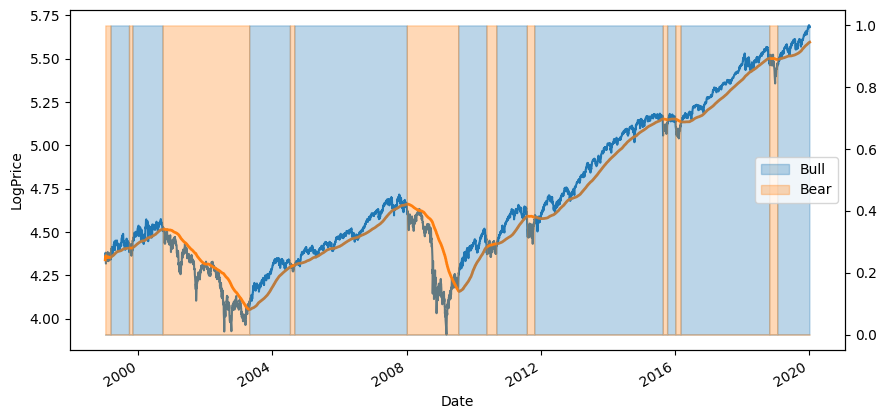

In [13]:
plot(jump.labels_, start_date = TRAIN_START, end_date = TRAIN_END)

In [14]:
print("Scaled Cluster Centroids:", pd.DataFrame(jump.centers_, index=["Bull", "Bear"], columns=Xtrain.columns), sep="\n" + "-"*50 + "\n")

Scaled Cluster Centroids:
--------------------------------------------------
      logprice_z30  logprice_z90  logprice_z180  logprice_z365  logprice_z1461
Bull      0.605256      0.988299       1.265958       1.413338        1.168081
Bear     -0.459350     -0.878988      -1.142502      -1.111273       -0.765694


/tmp/ipykernel_492/1001219183.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(spy_df.loc[start_date: end_date, 'ma200'], label='ma200', linewidth=2)


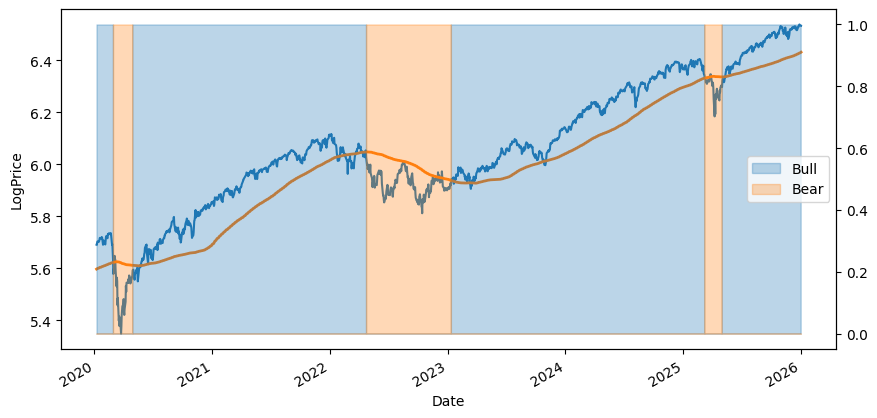

In [15]:
plot(jump.predict(Xtest), start_date = TEST_START, end_date = TEST_END)

## 3. Setting up backtester

In [152]:
spy_returns = pd.DataFrame(spy_df["Close"].pct_change().shift(-1).fillna(0), index = spy_df.index).rename(columns = {"Close": "SPY"})
#spy_returns.index = spy_returns.index.tz_localize('US/Eastern')

#spy_returns['USDOLLAR'] = 0.0
market_data = cp.UserProvidedMarketData(
    returns=spy_returns,
    cash_key='USDOLLAR',
    #trading_calendar=btc_returns.index 
)

tcost_model = cp.TcostModel(a=0, b=None)

market_sim = cp.MarketSimulator(market_data = market_data, costs = [tcost_model])

def transfer_data(labels, index):
    """Transfer (bear=1, bull=0) into (bear=0, bull=1)"""
    arr = np.where(labels == 0, 1, 0)
    cash = labels
    return pd.DataFrame({'SPY': arr, 'USDOLLAR': cash}, index=index)

def evaluate_model(predictor, X, start_time, end_time):
    labels = predictor(X)
    d = transfer_data(labels, X.index)
    policy = cp.FixedWeights(d)
    logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
    backtest_result = market_sim.run_backtest(policy, start_time=start_time, end_time=end_time)
    logging.getLogger('cvxportfolio').setLevel(logging.INFO)
    return backtest_result

def evaluate_buy_hold(X, start_time, end_time):
    policy = cp.FixedWeights(pd.DataFrame({'SPY': np.ones(len(X.index)), 'USDOLLAR': np.zeros(len(X.index))}, index=X.index))
    logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
    backtest_result = market_sim.run_backtest(policy, start_time=start_time, end_time=end_time)
    logging.getLogger('cvxportfolio').setLevel(logging.INFO)
    return backtest_result

In [17]:
spy_returns

,SPY
Date,
1999-01-04 16:00:00-05:00,-0.003545
1999-01-05 16:00:00-05:00,0.023385
1999-01-06 16:00:00-05:00,0.004471
1999-01-07 16:00:00-05:00,0.014342
1999-01-08 16:00:00-05:00,-0.003901
...,...
2025-12-24 16:00:00-05:00,0.003910
2025-12-26 16:00:00-05:00,-0.004489
2025-12-29 16:00:00-05:00,-0.000131


## 4. PnL optimization/other performance metrics optimization

In [18]:
evaluate_model(jump.predict, Xtrain, TRAIN_START, TRAIN_END)


#################################################################
Universe size                                                   2
Initial timestamp                       2000-01-03 21:00:00+00:00
Final timestamp                         2020-01-06 21:00:00+00:00
Number of periods                                            5034
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  7.358e+06
Profit (USDOLLAR)                                       6.358e+06
                                                                 
Avg. return (annualized)                                    10.6%
Volatility (annualized)                                     11.0%
Avg. excess return (annualized)                              8.8%
Excess volatility (annualized)                              11.0%
                                                                 
Avg. growth rate (annualized)                               10.0%
Avg. exce

In [53]:
def hyperparam_tuning(hyper_params):
    M = 0
    argM = 1
    for penalty in hyper_params:
        jump =  JumpModel(n_components = NO_STATES, jump_penalty = penalty).fit(Xtrain)
        result = evaluate_model(jump.predict, Xtrain, TRAIN_START, TRAIN_END).sharpe_ratio
        print(penalty, result)
        if result > M:
            argM = penalty
            M = result
            
    return argM

#hyperparam_tuning([5, 10, 20, 50, 100])
OPT_PENAL = hyperparam_tuning([25, 30, 40, 50, 100])


25 0.7418897936583079
30 0.793999387211425
40 0.8051683998372995
50 0.8051683998372995
100 0.7963254257808507


In [20]:
result = evaluate_buy_hold(Xtrain, TRAIN_START, TRAIN_END)
result


#################################################################
Universe size                                                   2
Initial timestamp                       2000-01-03 21:00:00+00:00
Final timestamp                         2020-01-06 21:00:00+00:00
Number of periods                                            5034
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  3.112e+06
Profit (USDOLLAR)                                       2.112e+06
                                                                 
Avg. return (annualized)                                     7.5%
Volatility (annualized)                                     18.8%
Avg. excess return (annualized)                              5.7%
Excess volatility (annualized)                              18.8%
                                                                 
Avg. growth rate (annualized)                                5.7%
Avg. exce

## 5. Out-of-sample performance

In [21]:
#TRAIN_END = pd.Timestamp("2024-01-06 16:00:00").tz_localize('US/Eastern')
#TEST_START = pd.Timestamp("2024-01-07 16:00:00").tz_localize('US/Eastern')

In [210]:
result = evaluate_buy_hold(Xtest, TEST_START, TEST_END)
result


#################################################################
Universe size                                                   2
Initial timestamp                       2024-01-08 21:00:00+00:00
Final timestamp                         2025-12-31 21:00:00+00:00
Number of periods                                             498
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  1.457e+06
Profit (USDOLLAR)                                       4.575e+05
                                                                 
Avg. return (annualized)                                    20.4%
Volatility (annualized)                                     16.4%
Avg. excess return (annualized)                             15.9%
Excess volatility (annualized)                              16.4%
                                                                 
Avg. growth rate (annualized)                               19.1%
Avg. exce

In [54]:
jump = JumpModel(n_components = NO_STATES, jump_penalty = OPT_PENAL).fit(X[TRAIN_START:TRAIN_END])
result = evaluate_model(jump.predict, Xtest, TEST_START, TEST_END)
result


#################################################################
Universe size                                                   2
Initial timestamp                       2020-01-07 21:00:00+00:00
Final timestamp                         2025-12-31 21:00:00+00:00
Number of periods                                            1505
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  2.363e+06
Profit (USDOLLAR)                                       1.363e+06
                                                                 
Avg. return (annualized)                                    15.4%
Volatility (annualized)                                     13.8%
Avg. excess return (annualized)                             12.7%
Excess volatility (annualized)                              13.8%
                                                                 
Avg. growth rate (annualized)                               14.4%
Avg. exce

/home/ndntam/.local/lib/python3.12/site-packages/cvxportfolio/result.py:1014: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # pragma: no cover


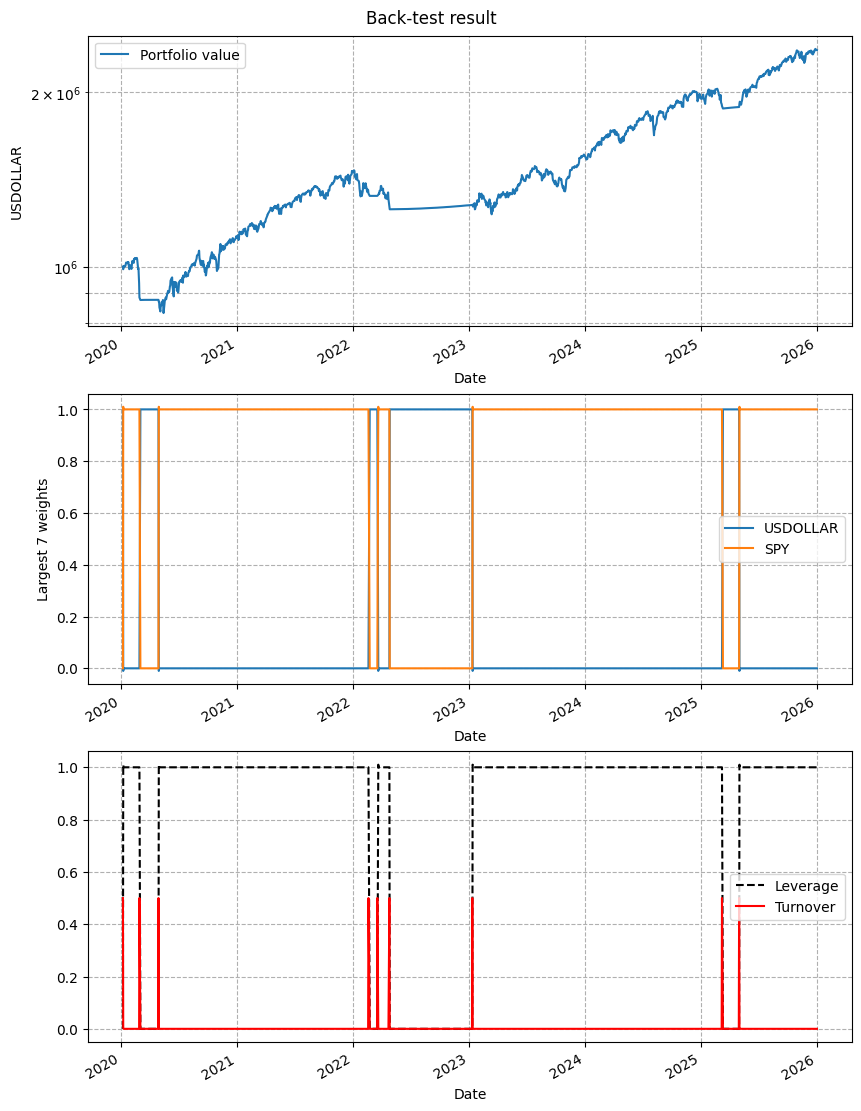

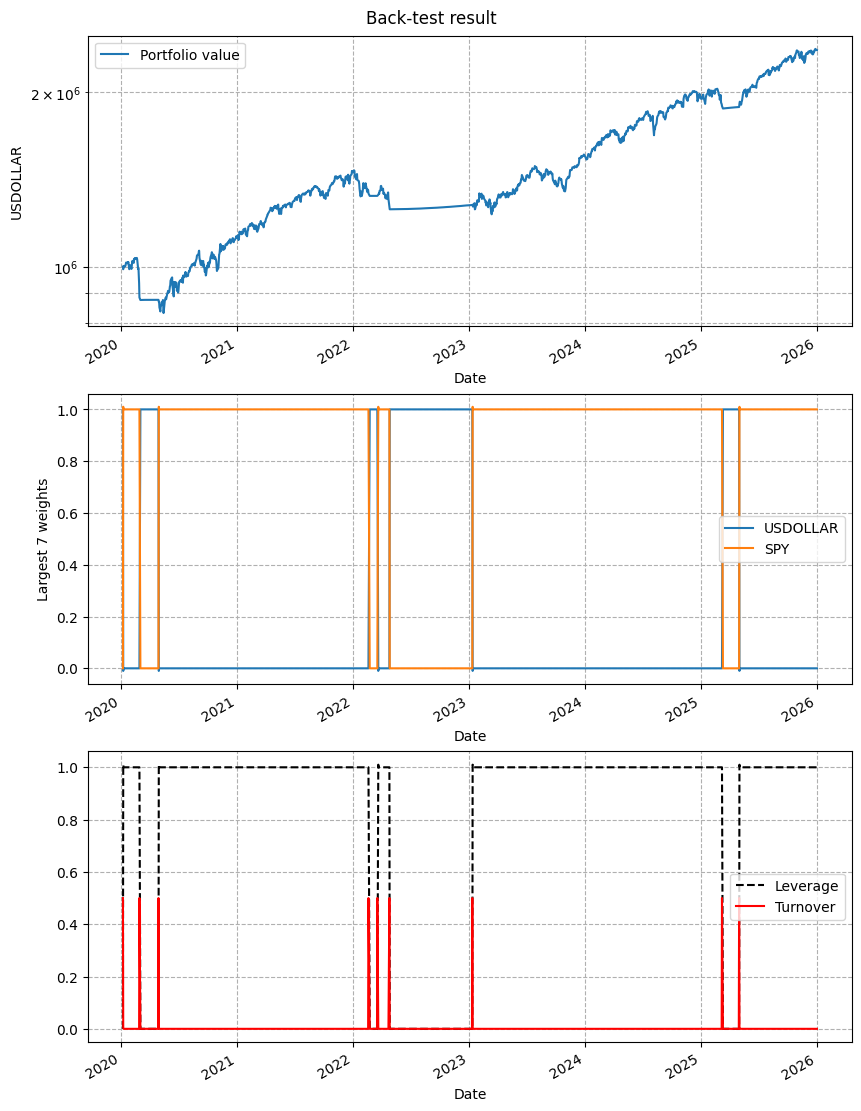

In [55]:
result.plot()

### Comparing to simple signals

In [108]:
def ma200(X):
    return spy_df.loc[X.index, 'logprice'] <= spy_df.loc[X.index, 'ma200']
sum(ma200(Xtrain) == jump.labels_)/len(dates)

0.9284497444633731

In [115]:
(ma200(Xtest).diff().abs().sum())/len(Xtest.index)

0.02524916943521595

In [116]:
(jump.predict(Xtest).diff().abs().sum())/len(Xtest.index)

np.float64(0.003986710963455149)

In [109]:
result = evaluate_model(jump.predict, Xtest, TEST_START, TEST_END)
result

/home/ndntam/.local/lib/python3.12/site-packages/cvxportfolio/result.py:1014: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # pragma: no cover


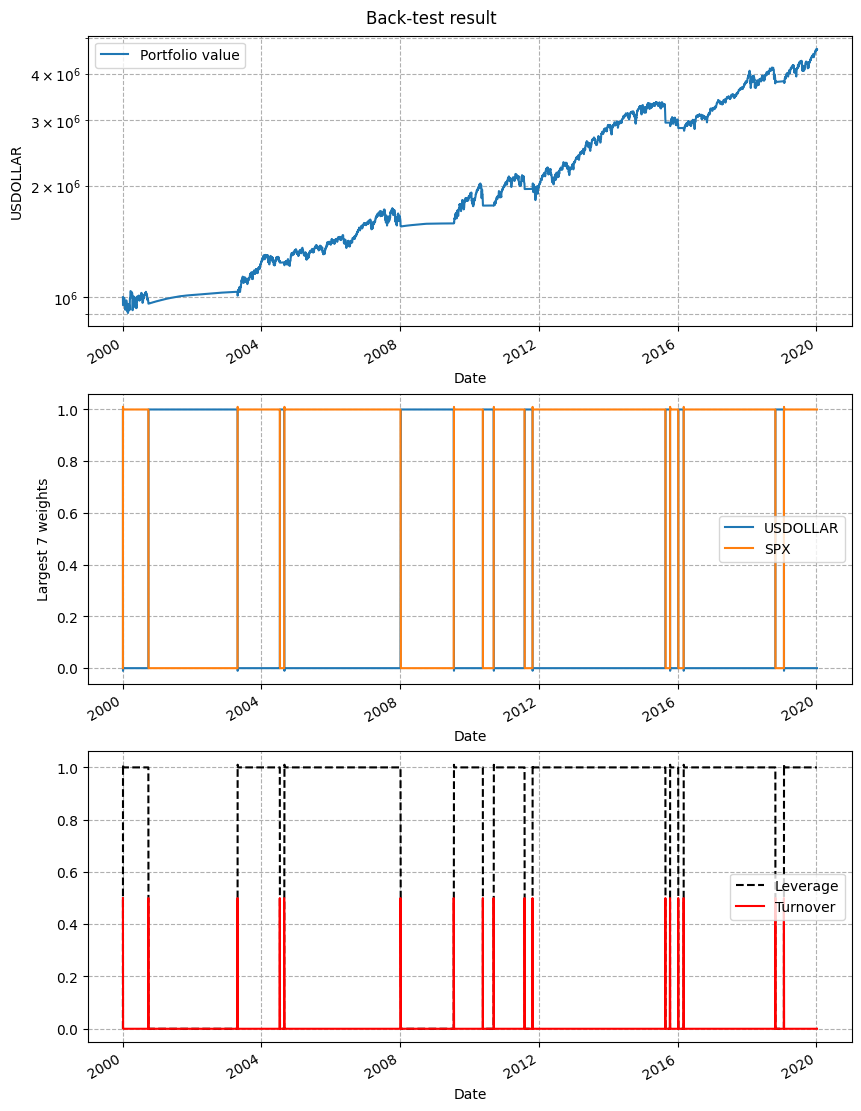

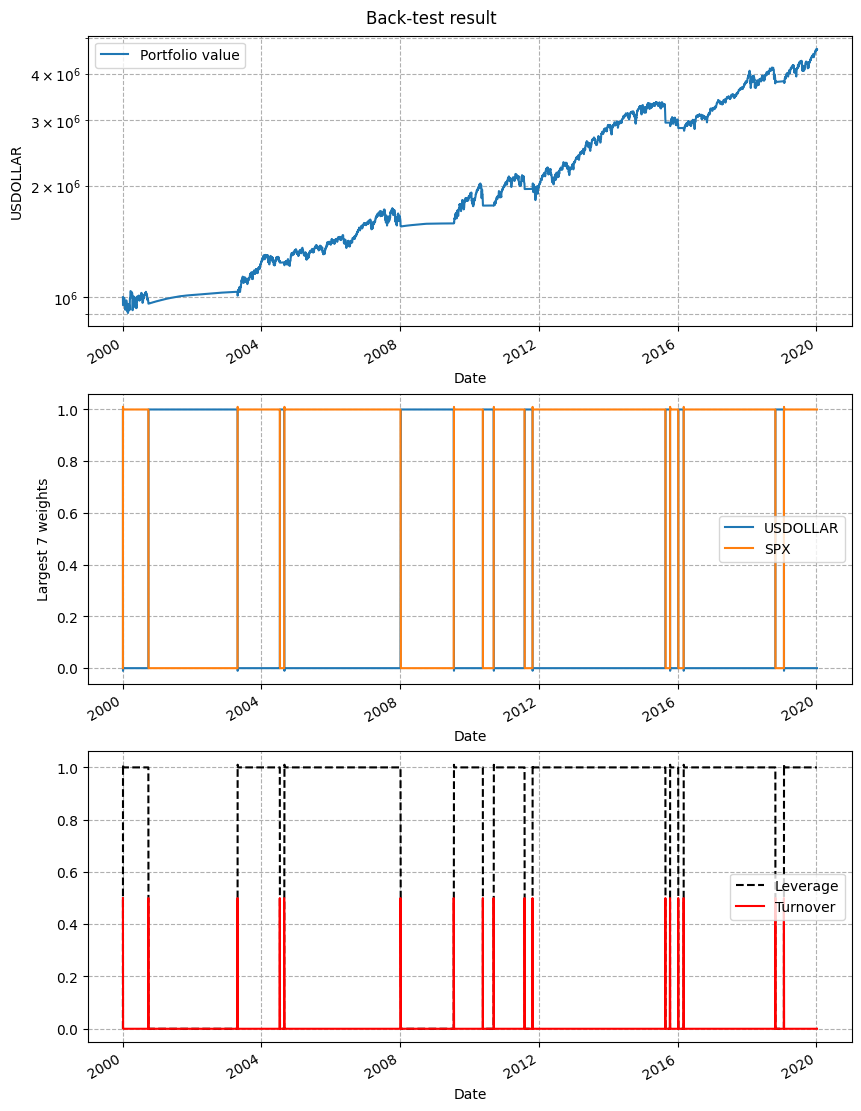

In [110]:
result.plot()

In [111]:
result = evaluate_model(ma200, Xtest, TEST_START, TEST_END)
result


#################################################################
Universe size                                                   2
Initial timestamp                       2020-01-07 21:00:00+00:00
Final timestamp                         2025-12-31 21:00:00+00:00
Number of periods                                            1505
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  1.200e+06
Profit (USDOLLAR)                                       1.996e+05
                                                                 
Avg. return (annualized)                                     3.9%
Volatility (annualized)                                     12.8%
Avg. excess return (annualized)                              1.2%
Excess volatility (annualized)                              12.8%
                                                                 
Avg. growth rate (annualized)                                3.0%
Avg. exce

/home/ndntam/.local/lib/python3.12/site-packages/cvxportfolio/result.py:1014: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # pragma: no cover


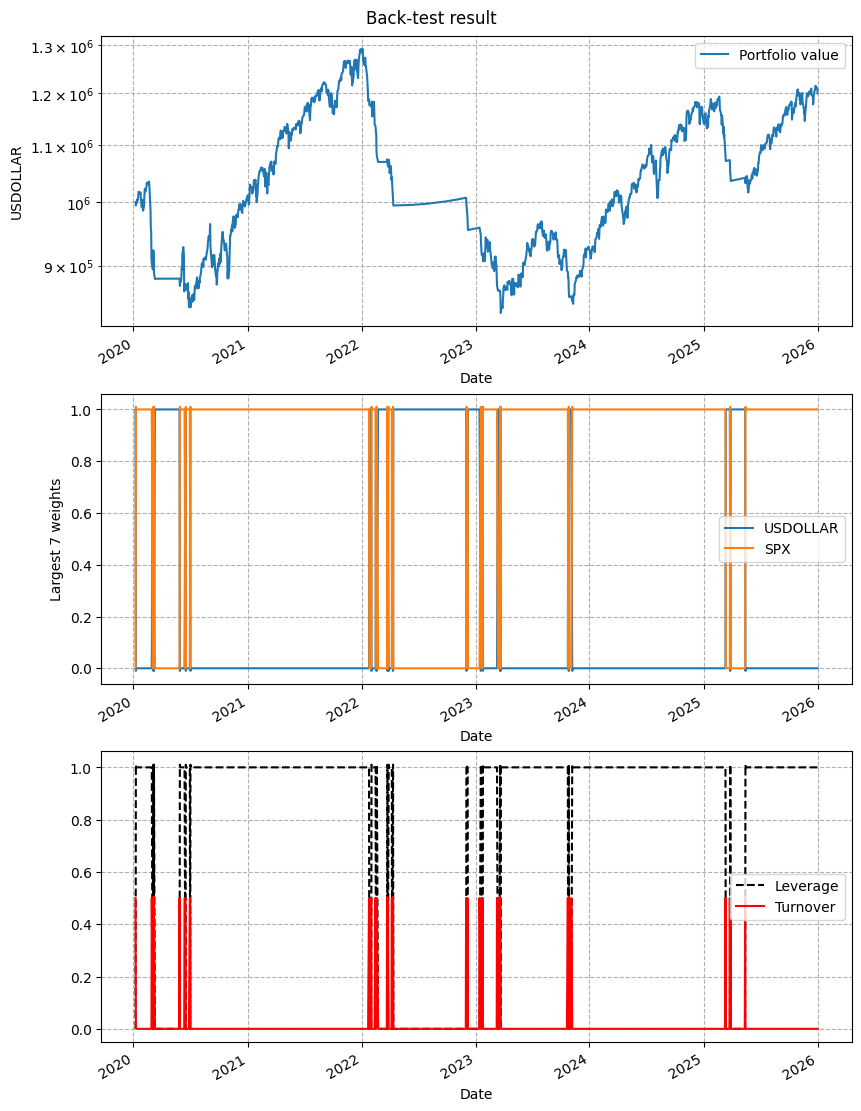

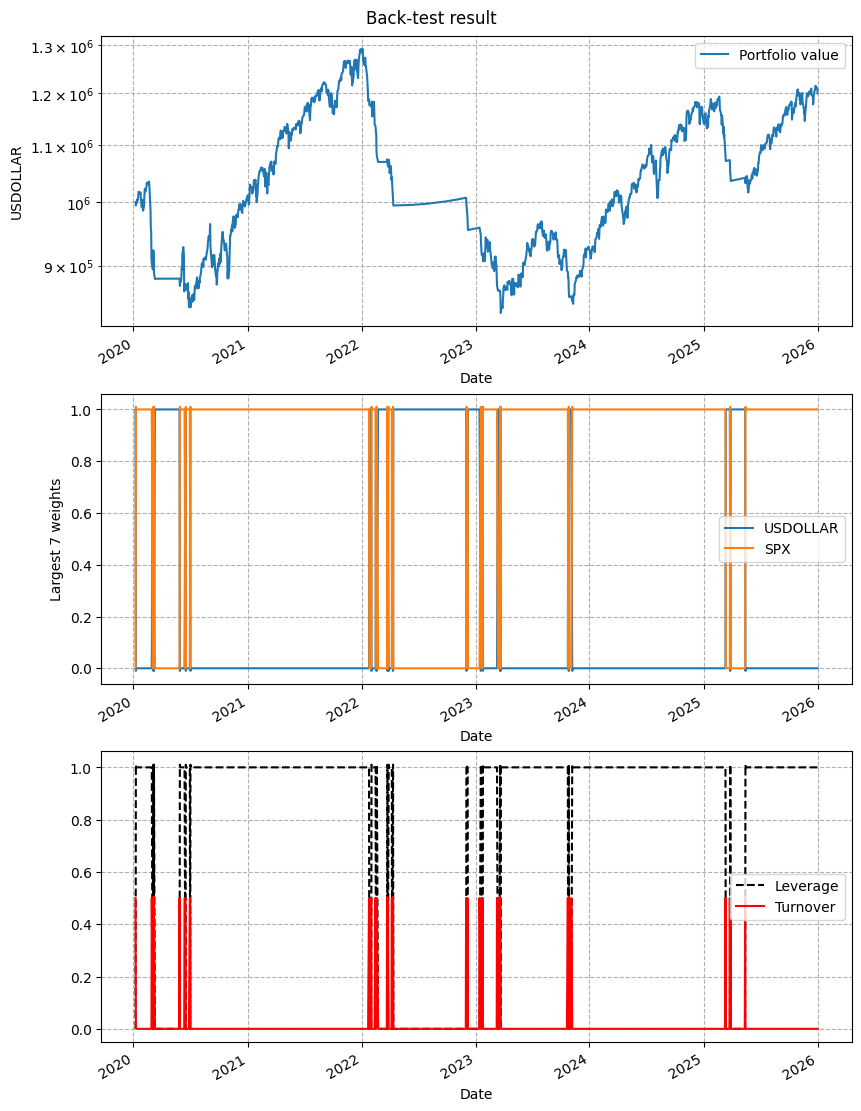

In [112]:
result.plot()